<a href="https://colab.research.google.com/github/MaksudaMostofaMunmun/LAB_TEST_REPO/blob/main/thesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import os

os.environ['KAGGLE_USERNAME'] = "maksudamunmun17"
os.environ['KAGGLE_KEY'] = "1c87406213e881ec4cc369143781310e"

import kagglehub

path = kagglehub.dataset_download("paultimothymooney/breast-histopathology-images")

print("Dataset successfully downloaded!")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'breast-histopathology-images' dataset.
Dataset successfully downloaded!
Path to dataset files: /kaggle/input/breast-histopathology-images


Total Images Found: 555048
Sample Image Loaded: /kaggle/input/breast-histopathology-images/10295/0/10295_idx5_x1351_y1101_class0.png


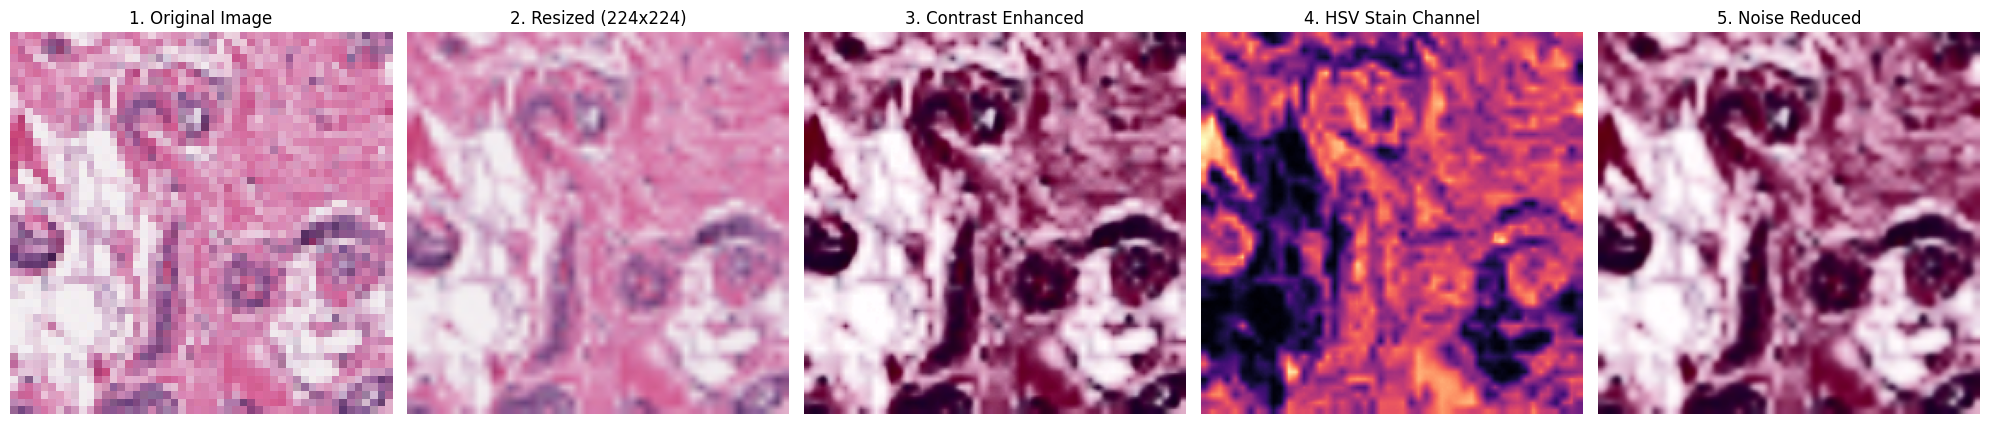

In [6]:
# Image Processing & Visualization
import os
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

DATASET_PATH = '/kaggle/input/breast-histopathology-images'

all_images = glob.glob(f"{DATASET_PATH}/**/*.png", recursive=True)
sample_image_path = all_images[0]
print(f"Total Images Found: {len(all_images)}")
print(f"Sample Image Loaded: {sample_image_path}")

def process_breast_cancer_image(img_path):

    original_img = cv2.imread(img_path)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

    # A. Resizing (224x224)
    resized_img = cv2.resize(original_img, (224, 224))

    # B. Contrast Enhancement (Histogram Equalization)
    img_yuv = cv2.cvtColor(resized_img, cv2.COLOR_RGB2YUV)
    img_yuv[:,:,0] = cv2.equalizeHist(img_yuv[:,:,0])
    enhanced_img = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

    # C. HSV Color Channel (Stain Differentiation)
    hsv_img = cv2.cvtColor(resized_img, cv2.COLOR_RGB2HSV)

    # D. Gaussian Denoising (Noise Reduction)
    denoised_img = cv2.GaussianBlur(enhanced_img, (3, 3), 0)

    return original_img, resized_img, enhanced_img, hsv_img, denoised_img

orig, res, enh, hsv, den = process_breast_cancer_image(sample_image_path)
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

axes[0].imshow(orig)
axes[0].set_title("1. Original Image")
axes[0].axis("off")

axes[1].imshow(res)
axes[1].set_title("2. Resized (224x224)")
axes[1].axis("off")

axes[2].imshow(enh)
axes[2].set_title("3. Contrast Enhanced")
axes[2].axis("off")

axes[3].imshow(hsv[:,:,1], cmap='magma')
axes[3].set_title("4. HSV Stain Channel")
axes[3].axis("off")

axes[4].imshow(den)
axes[4].set_title("5. Noise Reduced")
axes[4].axis("off")

plt.tight_layout()
plt.savefig("Image_Processing_Pipeline.png", dpi=300)
plt.show()

In [7]:
# Model Training (ResNet50 vs ViT)

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
import glob
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class BreastCancerDataset(Dataset):
    def __init__(self, file_paths, transform=None):
        self.file_paths = file_paths
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        image = Image.open(img_path).convert('RGB')

        label = 1 if 'class1' in img_path else 0

        if self.transform:
            image = self.transform(image)
        return image, label

all_images = glob.glob('/kaggle/input/breast-histopathology-images/**/*.png', recursive=True)
subset_images = all_images[:5000]

data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 80% Train, 20% Test
dataset = BreastCancerDataset(subset_images, transform=data_transform)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# CNN Model (ResNet50)
resnet_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 2)
resnet_model = resnet_model.to(device)

# Vision Transformer (ViT)
vit_model = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
vit_model.heads.head = nn.Linear(vit_model.heads.head.in_features, 2)
vit_model = vit_model.to(device)

def train_model(model, name, epochs=3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    print(f"\n Training Started: {name}")
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        acc = 100. * correct / total
        print(f"Epoch [{epoch+1}/{epochs}] -> Loss: {running_loss/len(train_loader):.4f} | Accuracy: {acc:.2f}%")

train_model(resnet_model, "ResNet50 (CNN)")
train_model(vit_model, "Vision Transformer (ViT)")

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 79.5MB/s]


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 167MB/s]



 Training Started: ResNet50 (CNN)
Epoch [1/3] -> Loss: 0.3177 | Accuracy: 86.85%
Epoch [2/3] -> Loss: 0.1771 | Accuracy: 92.95%
Epoch [3/3] -> Loss: 0.1269 | Accuracy: 95.28%

 Training Started: Vision Transformer (ViT)
Epoch [1/3] -> Loss: 0.3477 | Accuracy: 85.25%
Epoch [2/3] -> Loss: 0.2219 | Accuracy: 91.25%
Epoch [3/3] -> Loss: 0.1734 | Accuracy: 93.33%



 ResNet50_CNN Classification Report 
               precision    recall  f1-score   support

   Benign (0)       0.94      0.97      0.95       686
Malignant (1)       0.92      0.86      0.89       314

     accuracy                           0.94      1000
    macro avg       0.93      0.92      0.92      1000
 weighted avg       0.93      0.94      0.93      1000



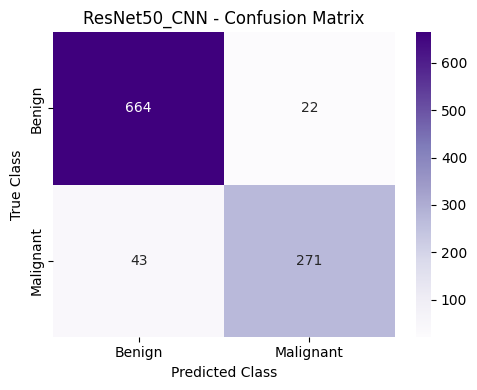


 Vision_Transformer_ViT Classification Report 
               precision    recall  f1-score   support

   Benign (0)       0.91      0.98      0.94       686
Malignant (1)       0.94      0.79      0.86       314

     accuracy                           0.92      1000
    macro avg       0.92      0.88      0.90      1000
 weighted avg       0.92      0.92      0.91      1000



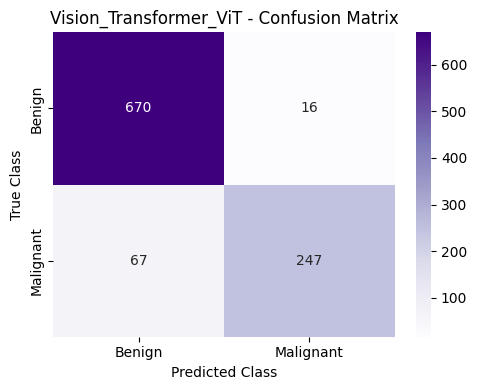

In [10]:
# Evaluation & Confusion Matrix

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_and_plot(model, model_name):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(f"\n {model_name} Classification Report ")
    print(classification_report(all_labels, all_preds, target_names=['Benign (0)', 'Malignant (1)']))

    # Confusion Matrix Plot
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.tight_layout()
    plt.savefig(f"{model_name}_confusion_matrix.png", dpi=300)
    plt.show()

evaluate_and_plot(resnet_model, "ResNet50_CNN")
evaluate_and_plot(vit_model, "Vision_Transformer_ViT")


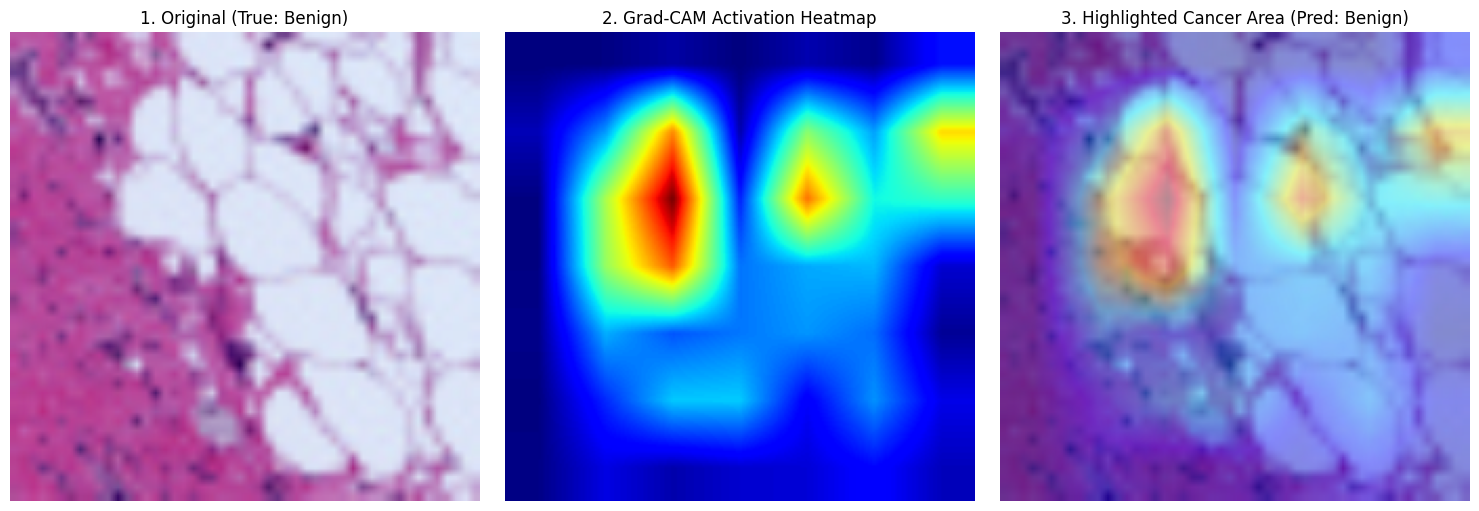

✅ Grad-CAM Explainable AI Visual successfully generated & saved!


In [9]:
# STEP 5: Explainable AI (Grad-CAM)

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

# Grad-CAM Class implementation
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Hooks for capturing gradients and activations
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_heatmap(self, input_image, target_class=None):
        self.model.eval()
        output = self.model(input_image)

        if target_class is None:
            target_class = torch.argmax(output, dim=1).item()

        self.model.zero_grad()
        class_score = output[0, target_class]
        class_score.backward()

        gradients = self.gradients.data.cpu().numpy()[0]
        activations = self.activations.data.cpu().numpy()[0]

        weights = np.mean(gradients, axis=(1, 2))
        cam = np.zeros(activations.shape[1:], dtype=np.float32)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (224, 224))
        cam = cam - np.min(cam)
        cam = cam / np.max(cam)
        return cam, target_class

#ResNet50
grad_cam = GradCAM(resnet_model, resnet_model.layer4[-1])

sample_img, true_label = test_dataset[0]
input_tensor = sample_img.unsqueeze(0).to(device)

heatmap, pred_class = grad_cam.generate_heatmap(input_tensor)

# Original vs Grad-CAM Heatmap
orig_img = sample_img.permute(1, 2, 0).cpu().numpy()
orig_img = (orig_img - orig_img.min()) / (orig_img.max() - orig_img.min())

heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0

overlay = 0.6 * orig_img + 0.4 * heatmap_color
overlay = overlay / np.max(overlay)

class_names = ['Benign', 'Malignant']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(orig_img)
axes[0].set_title(f"1. Original (True: {class_names[true_label]})")
axes[0].axis("off")

axes[1].imshow(heatmap, cmap='jet')
axes[1].set_title("2. Grad-CAM Activation Heatmap")
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title(f"3. Highlighted Cancer Area (Pred: {class_names[pred_class]})")
axes[2].axis("off")

plt.tight_layout()
plt.savefig("GradCAM_Explainable_AI.png", dpi=300)
plt.show()

print("Grad-CAM Explainable AI Visual successfully generated & saved!")

In [10]:
# ==========================================
# STEP 6: Hybrid Model (CNN + Transformer)
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# ১. কাস্টম হাইব্রিড আর্কিটেকচার ডিফাইন করা
class HybridCNNTransformer(nn.Module):
    def __init__(self, num_classes=2):
        super(HybridCNNTransformer, self).__init__()

        # CNN Feature Extractor (ResNet50)
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.cnn_features = nn.Sequential(*list(resnet.children())[:-1])  # Output: 2048

        # Transformer Feature Extractor (ViT)
        vit = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
        self.vit_backbone = vit
        self.vit_fc = nn.Linear(1000, 512)

        # FC Layer for CNN features reduction
        self.cnn_fc = nn.Linear(2048, 512)

        # Combined Classifier Head (Fusion)
        self.classifier = nn.Sequential(
            nn.Linear(512 + 512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # Extract CNN features
        cnn_out = self.cnn_features(x)
        cnn_out = torch.flatten(cnn_out, 1)
        cnn_out = self.cnn_fc(cnn_out)

        # Extract Transformer features
        vit_out = self.vit_backbone(x)
        vit_out = self.vit_fc(vit_out)

        # Feature Fusion (Concat)
        combined = torch.cat((cnn_out, vit_out), dim=1)

        # Final Output
        out = self.classifier(combined)
        return out

# ২. হাইব্রিড মডেল ইনিশিয়ালাইজেশন
hybrid_model = HybridCNNTransformer(num_classes=2).to(device)

# ৩. ট্রেনিং এবং ইভালুয়েশন
print("\n🚀 Training Started: Hybrid Model (ResNet50 + ViT Fusion)")
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(hybrid_model.parameters(), lr=0.00005)

hybrid_model.train()
epochs = 3

for epoch in range(epochs):
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = hybrid_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    acc = 100. * correct / total
    print(f"Epoch [{epoch+1}/{epochs}] -> Loss: {running_loss/len(train_loader):.4f} | Hybrid Accuracy: {acc:.2f}%")

print("✅ হাইব্রিড মডেল ট্রেনিং সম্পন্ন হয়েছে!")


🚀 Training Started: Hybrid Model (ResNet50 + ViT Fusion)
Epoch [1/3] -> Loss: 0.3061 | Hybrid Accuracy: 87.03%
Epoch [2/3] -> Loss: 0.1604 | Hybrid Accuracy: 94.05%
Epoch [3/3] -> Loss: 0.1023 | Hybrid Accuracy: 96.15%
✅ হাইব্রিড মডেল ট্রেনিং সম্পন্ন হয়েছে!
